# Load Required Modules

To-do - run models over larger DOG kernels //
batch-processing // 
end-stopping with bars oriented along receptive fields //

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from dataset import Dataset
import cv2
from model import Model
import helperFunctions as hf

# Pre-Processing

In [4]:
# Pre-processing Pipeline
dataset = Dataset(foldername="canva_env_pictures",
    sigma1=1, sigma2 = 3, ksize =15, stride=True, sigma_gauss=0.35
)


(640, 480)
(480, 640)
(640, 448)
(480, 640)
(480, 640)


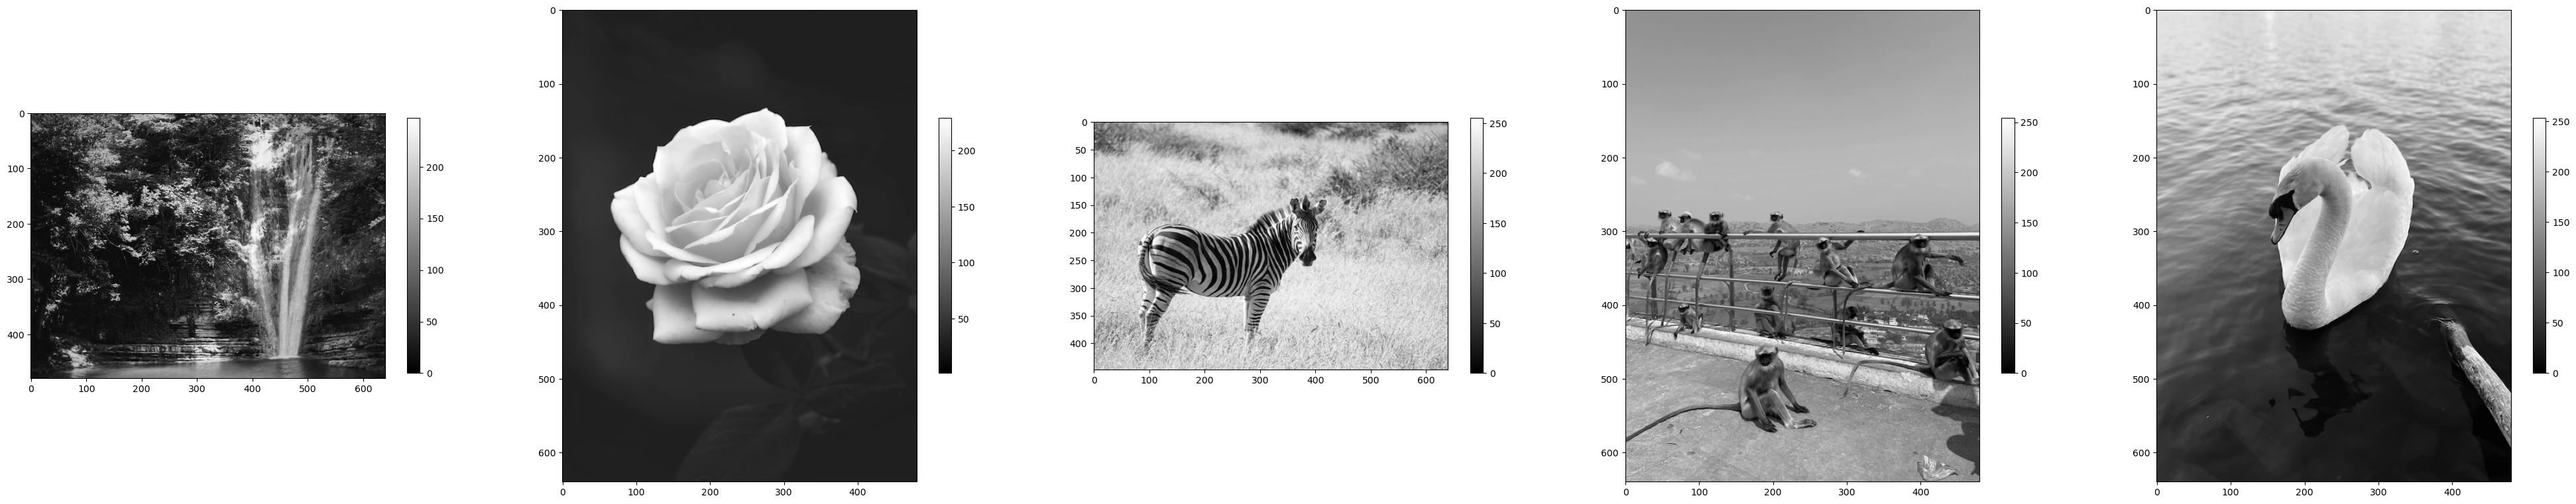

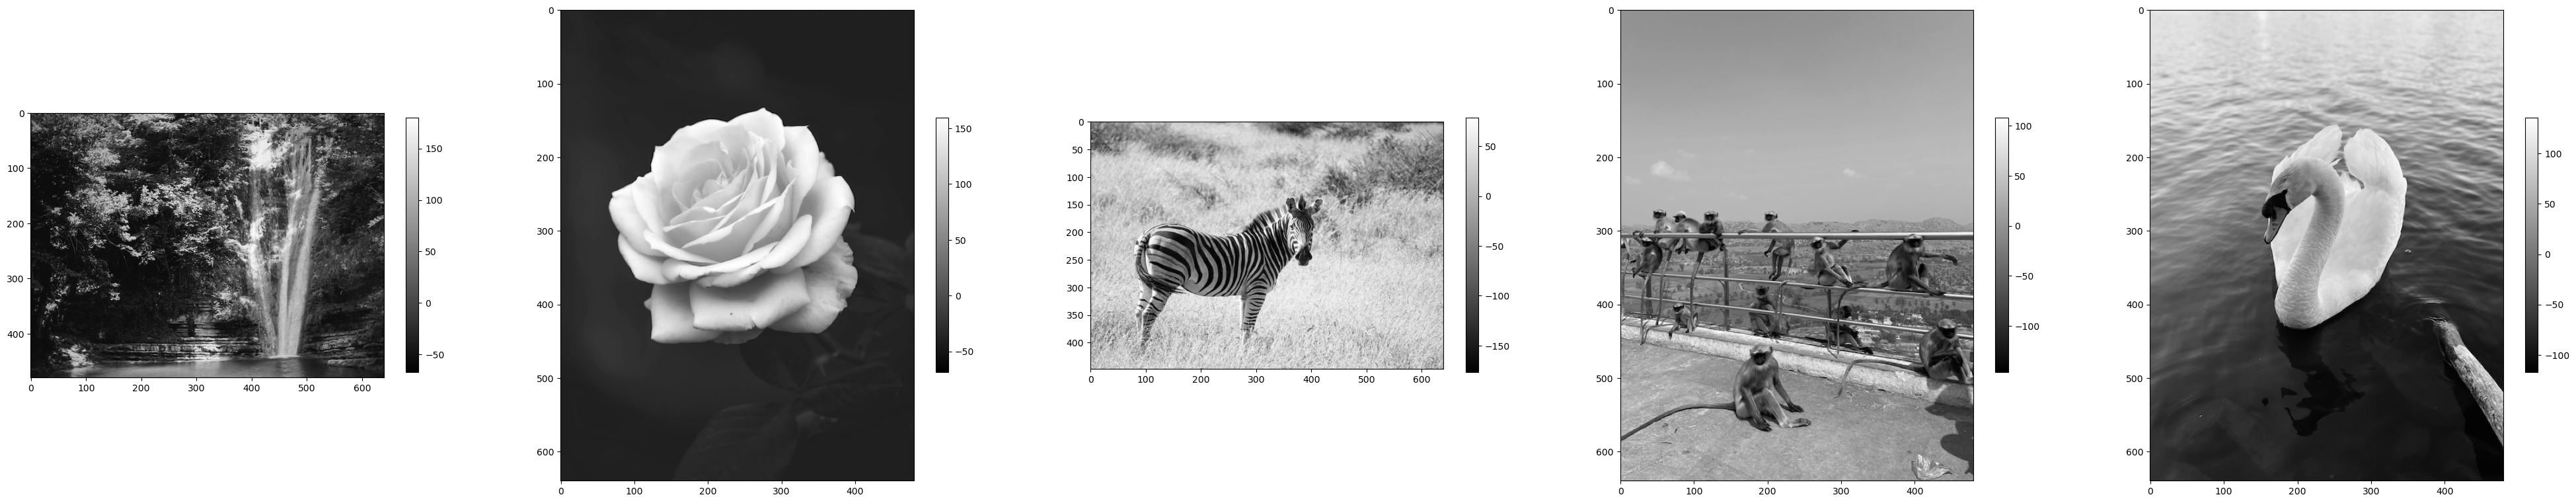

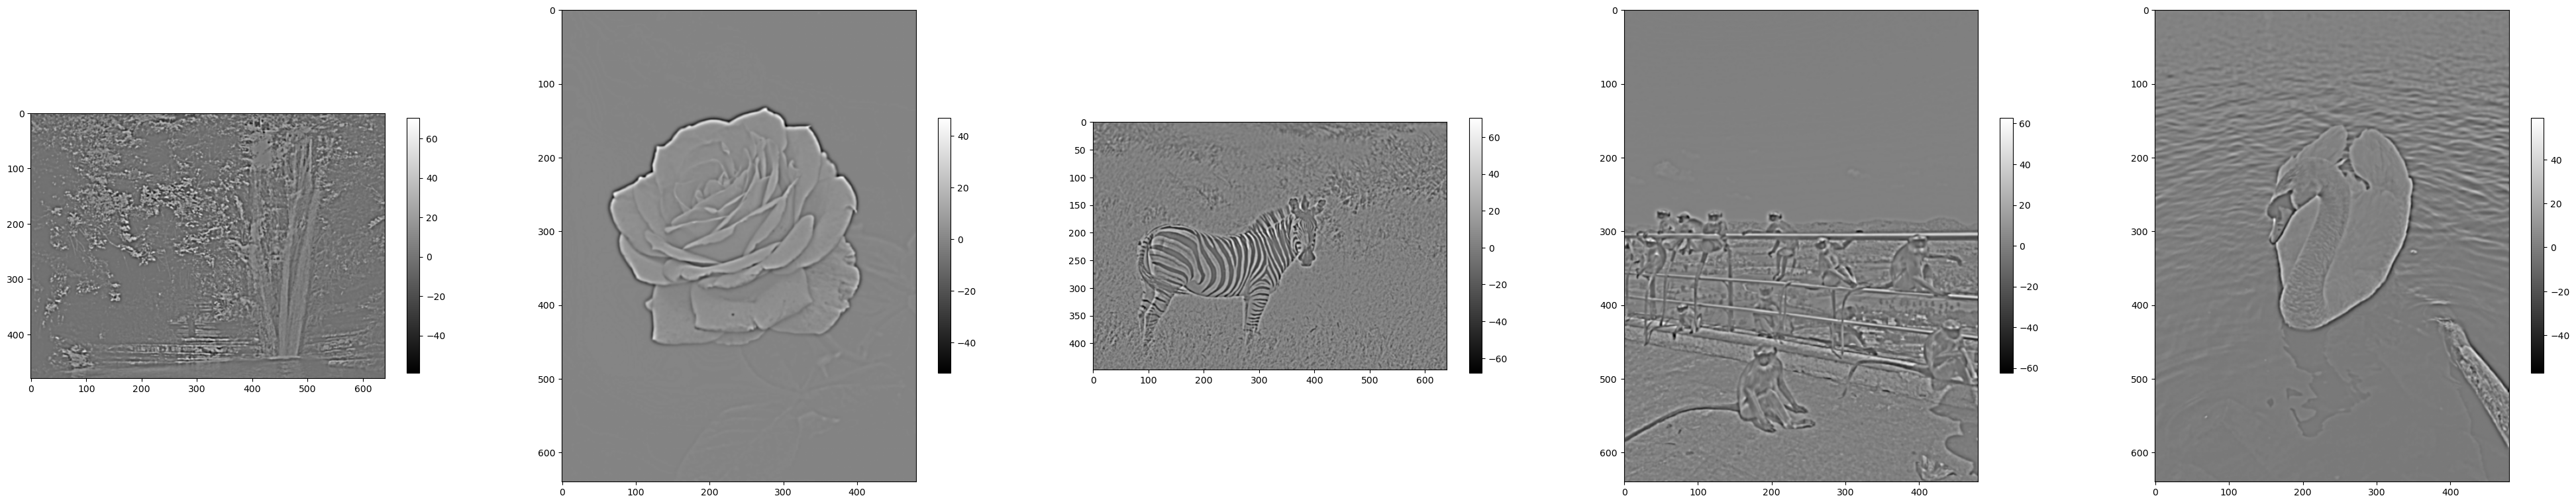

In [5]:
imgs = dataset.rawimages
_, ax = plt.subplots(ncols=5,nrows = int(len(imgs)/5), figsize=(50,10*int(len(imgs)/5)))
for i in range(len(imgs)):
    img = imgs[i]
    x=ax[i].imshow(img, cmap='grey', vmin=img.min(), vmax=img.max())
    plt.colorbar(x, shrink=0.5)
    
plt.savefig("figures/original_images.jpg")
plt.show()

imgs = dataset.filteredimages
_, ax = plt.subplots(ncols=5,nrows = int(len(imgs)/5), figsize=(50,10*int(len(imgs)/5)))
for i in range(len(imgs)):
    img = imgs[i]
    x=ax[i].imshow(img, cmap='grey', vmin=img.min(), vmax=img.max())
    plt.colorbar(x, shrink=0.5)
plt.savefig("figures/filtered_images.jpg")
plt.show()

imgs = dataset.dogfilteredimages
_, ax = plt.subplots(ncols=5,nrows = int(len(imgs)/5), figsize=(50,10*int(len(imgs)/5)))
for i in range(len(imgs)):
    img = imgs[i]
    x=ax[i].imshow(img, cmap='grey', vmin=img.min(), vmax=img.max())
    plt.colorbar(x, shrink=0.5)
plt.savefig("figures/DoG_images.jpg")
plt.show()

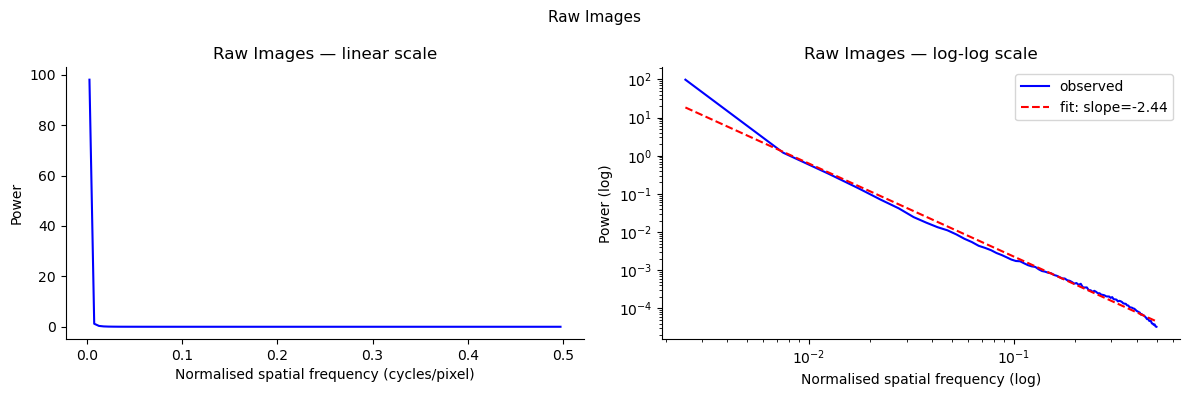

[Raw Images]
  slope        = -2.437
  n images     = 5
  interpretation:
  → natural / correlated  (expected ≈ -2.0)


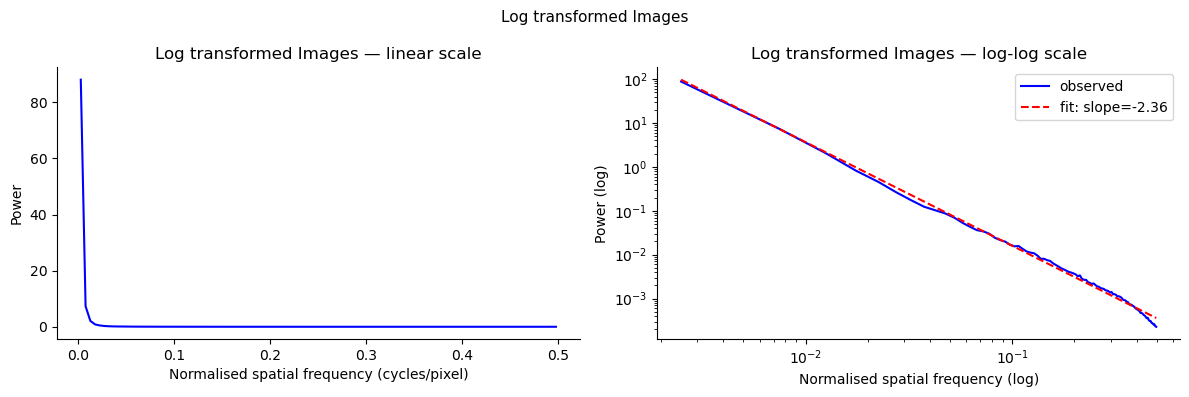

[Log transformed Images]
  slope        = -2.362
  n images     = 5
  interpretation:
  → natural / correlated  (expected ≈ -2.0)


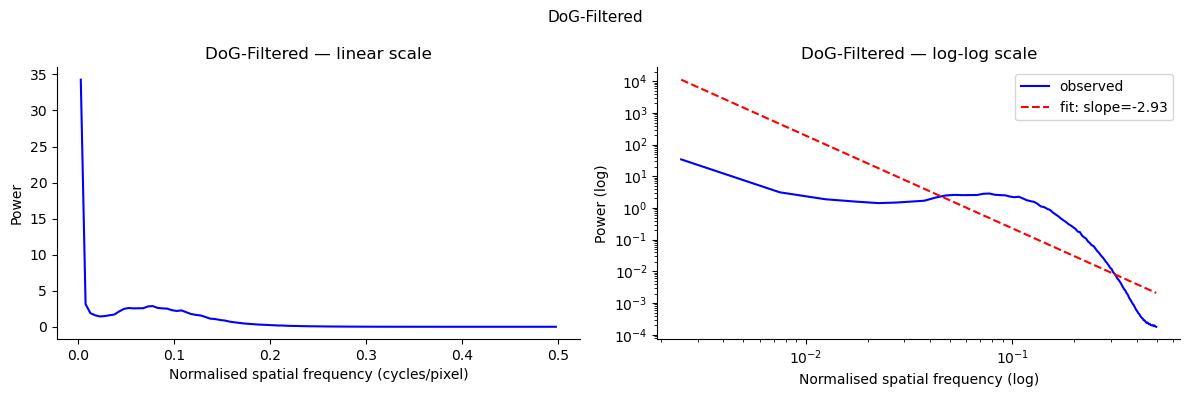

[DoG-Filtered]
  slope        = -2.929
  n images     = 5
  interpretation:
  → natural / correlated  (expected ≈ -2.0)


In [ ]:
freqs, psd, slope = hf.plot_power_spectrum(dataset.rawimages,     "Raw Images")
freqs, psd, slope = hf.plot_power_spectrum(dataset.filteredimages,     "Log transformed Images")
freqs, psd, slope = hf.plot_power_spectrum(dataset.dogfilteredimages,     "DoG-Filtered")

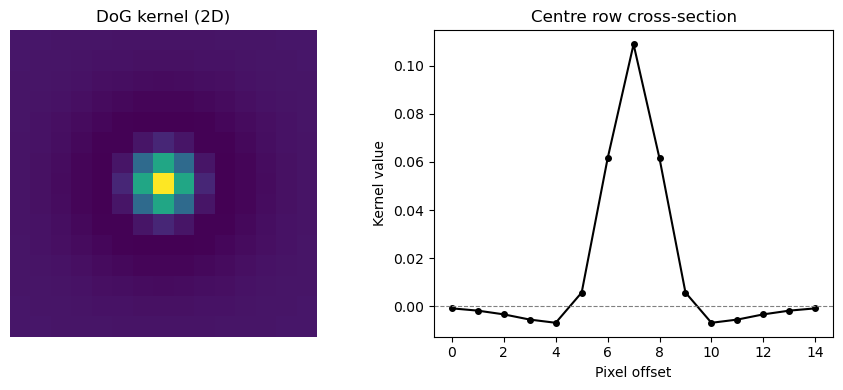

In [6]:
dataset.visualize_dog_kernel()

# Dense Coding

In [6]:
model = Model(iteration=50, alpha2 = 0.05,lambd2 = 0.01,lambd1=0.1, k1=0.1, k2_init=0.01, sigma_sq_td=5)#(iteration=50, sigma_sq_td=5, k1=0.05, k2_init=0.01, lambd2=0.01)#, alpha2 = 15,lambd2 = 0.1,lambd1=0.1, k1=0.5, k2_init=0.5, alpha1 = 5, sigma_sq=1, sigma_sq_td=0.5) #(iteration=50, alpha2 = 0.5,lambd2 = 0.01, k1=0.05) 

In [7]:
for i in range(1):
    model.train(dataset)

Sample0
Sample500
Sample1000
Sample1500
Sample2000
Sample2500
Sample3000
Sample3500
Sample4000
Sample4500
Sample5000
Sample5500
Sample6000
Sample6500
Sample7000
Sample7500
Sample8000
Sample8500
Sample9000
Sample9500
Sample10000
Sample10500
Sample11000
Sample11500
Sample12000
Sample12500
Sample13000
Sample13500
Sample14000
Sample14500
Sample15000
Sample15500
Sample16000
Sample16500
Sample17000
Sample17500
Sample18000
Sample18500
Sample19000
Sample19500
Sample20000
Sample20500
Sample21000
Sample21500
Sample22000
Sample22500
Sample23000
Sample23500
Sample24000
Sample24500
Sample25000
Sample25500
Sample26000
Sample26500
Sample27000
Sample27500
Sample28000
Sample28500
Sample29000
Sample29500
Sample30000
Sample30500
Sample31000
Sample31500
Sample32000
Sample32500
Sample33000
Sample33500
Sample34000
Sample34500
Sample35000
Sample35500
Sample36000
Sample36500
Sample37000
Sample37500
Sample38000
Sample38500
Sample39000
Sample39500
Sample40000
Sample40500
Sample41000
Sample41500
Sample42000
Samp

In [ ]:
# 6 epochs so far (run 12)
#for i in range(3): # 3 epochs
#    model.train_batch(dataset, batch_size=500, shuffle=True, sparse=False)

Batch 0
Batch 50
Batch 100
train finished
Batch 0
Batch 50
Batch 100
train finished
Batch 0
Batch 50
Batch 100
train finished


In [8]:
model_dense = model

In [ ]:
# load model instead

#modelname = "modelResults/workingmodel_dense_model_50iter_1epoch_55000patches"
#model_dense=model.load(modelname)

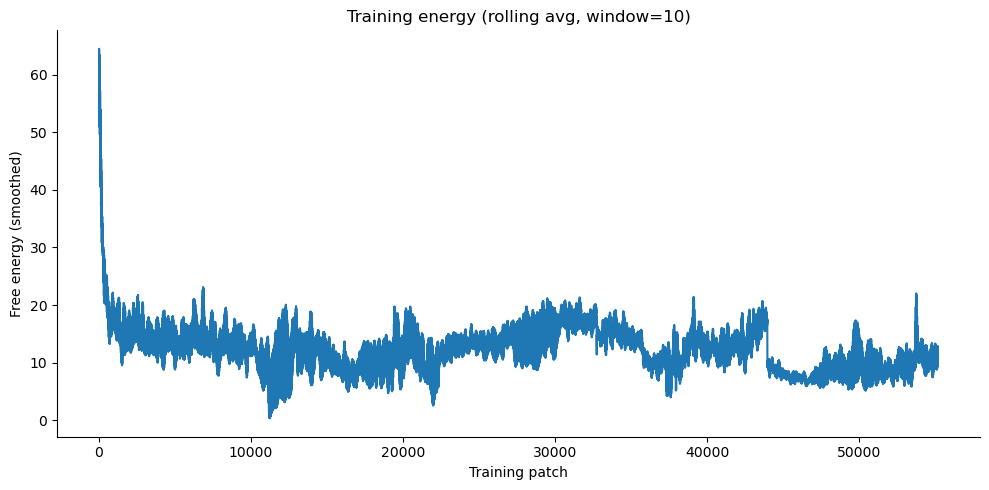

Initial energy (avg first 100):  54.05
Final energy   (avg last  100):  10.16
Reduction: 81.2%


In [38]:
plot_energy(model_dense.energy,window=10

            , savefile="dense_energy.jpg")


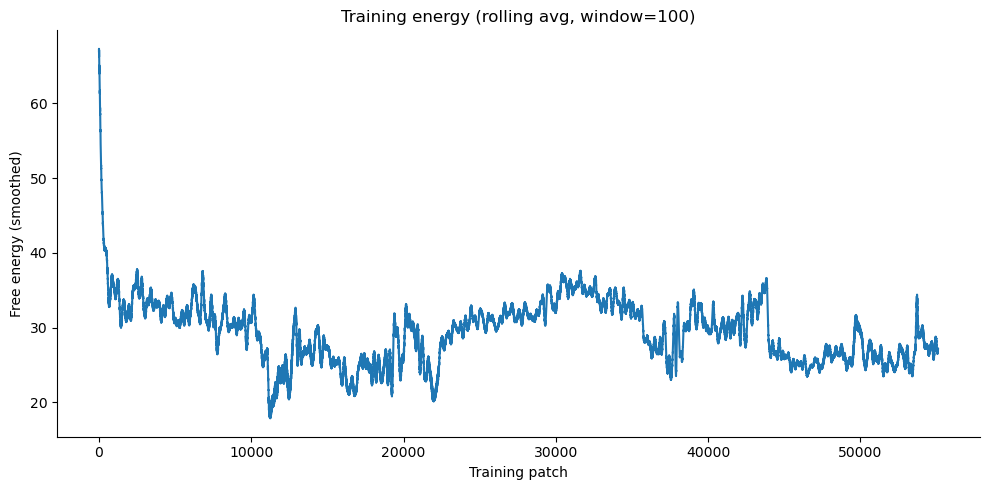

Initial energy (avg first 100):  66.98
Final energy   (avg last  100):  27.12
Reduction: 59.5%


In [39]:

#plot_energy(np.array(model_dense.energy[:50]))#+np.array(model.prior_r)+np.array(model.prior_U)+np.array(model.td_error))

plot_energy(np.array(model_dense.prior_r) + np.array(model_dense.prior_rh) + np.array(model_dense.prior_U) + np.array(model_dense.prior_uh)+np.array(model_dense.energy)+np.array(model_dense.energy_l2),window=100, savefile="figures/dense_energy.jpg")


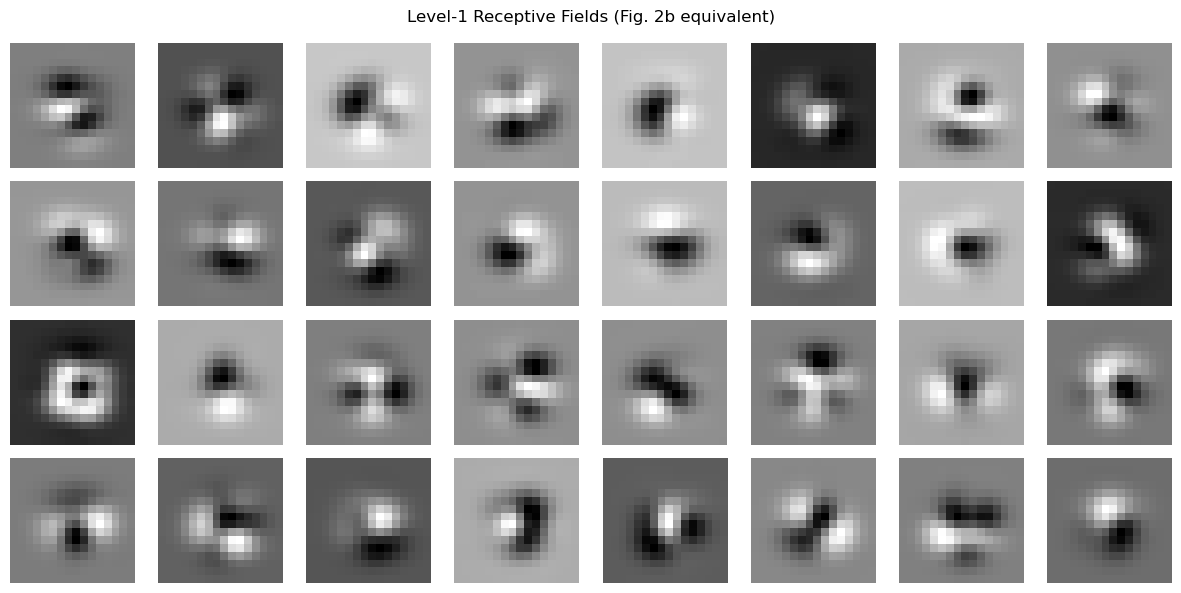

In [ ]:
fig, ax = plt.subplots(4, 8, figsize=(12, 6))
    
#u1 = model.Us[1][:,i].reshape(16,16)
#u1 = cv2.resize(u1, None, fx=4, fy=4, interpolation=cv2.INTER_NEAREST)
#imageio.imwrite("result/u1_{:0>2}.png".format(i), u1)

ax = ax.flatten()
for i in range(32):
    u1 = model_dense.Us[1][:,i].reshape(16,16)
    
    ax[i].imshow(u1, cmap='gray', interpolation='nearest')
    ax[i].axis('off')
fig.suptitle("Level-1 Receptive Fields (Fig. 2b equivalent)")
plt.tight_layout()

plt.savefig("figures/receptive_fields_l1_dense.png", dpi=150)
plt.show()

In [13]:
fig, ax = plt.subplots(8, 16, figsize=(120, 60))
ax = ax.flatten()
for i in range(128):
    u1 = model_dense.get_level2_rf(i)
    ax[i].imshow(u1, cmap='gray', interpolation='nearest')
    ax[i].axis('off')
fig.suptitle("Level-1 Receptive Fields (Fig. 2b equivalent)")
plt.tight_layout()

#plt.savefig("figures/receptive_fields_l2_dense.png", dpi=150)
plt.show()

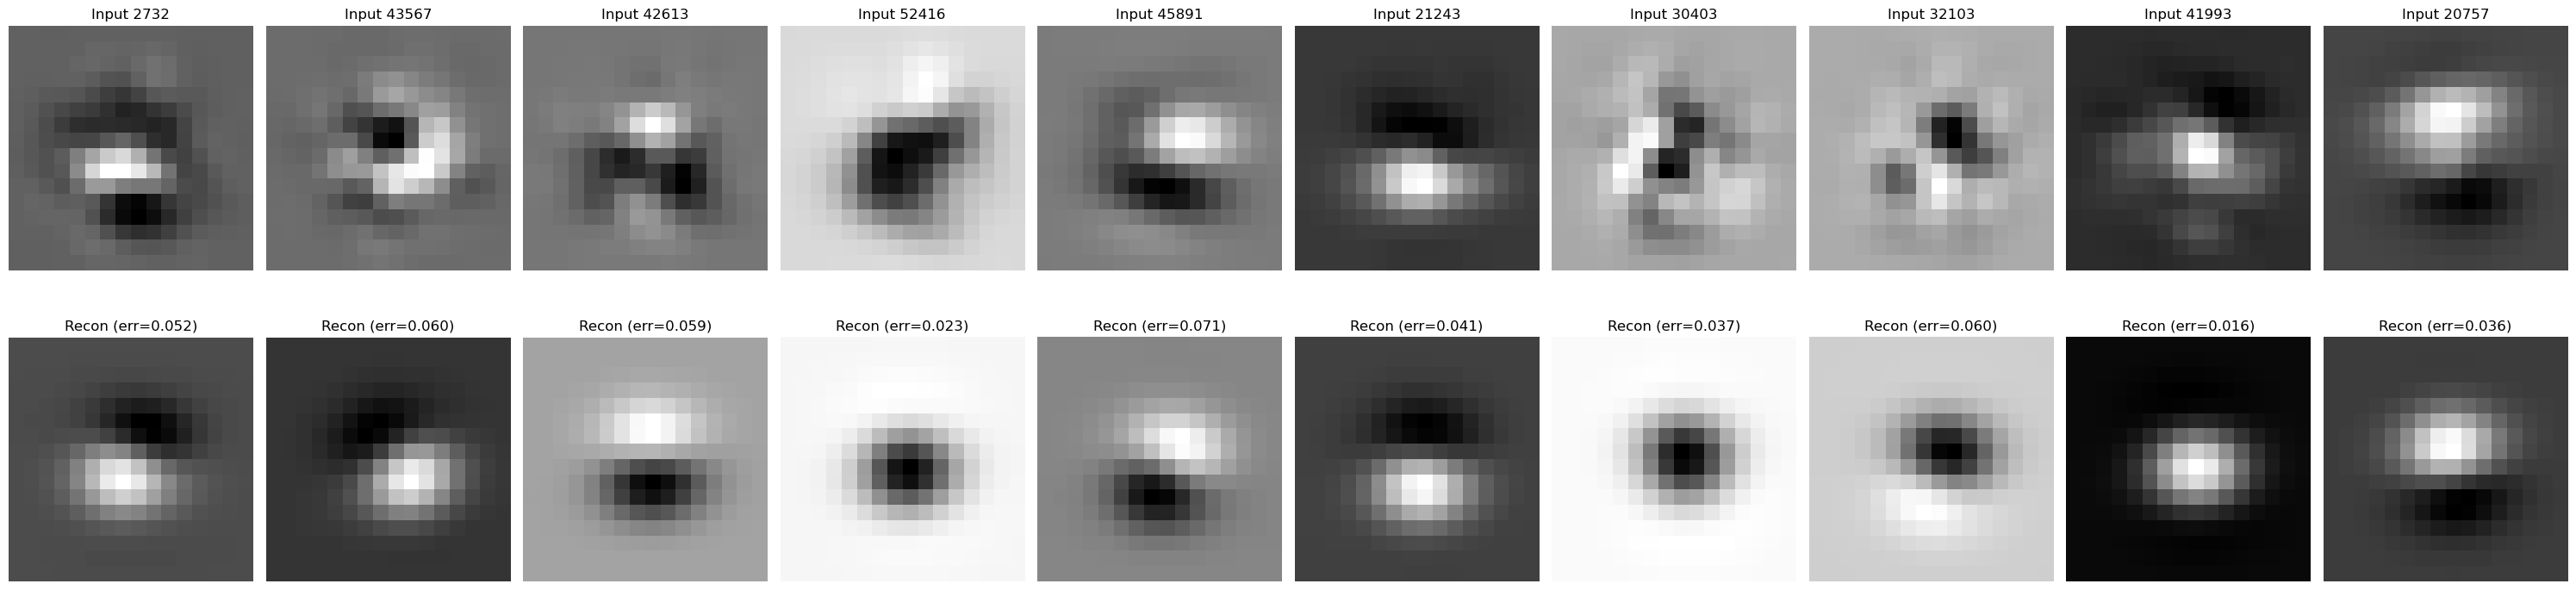

In [ ]:
hf.plot_reconstructions(model_dense, dataset, n=10)

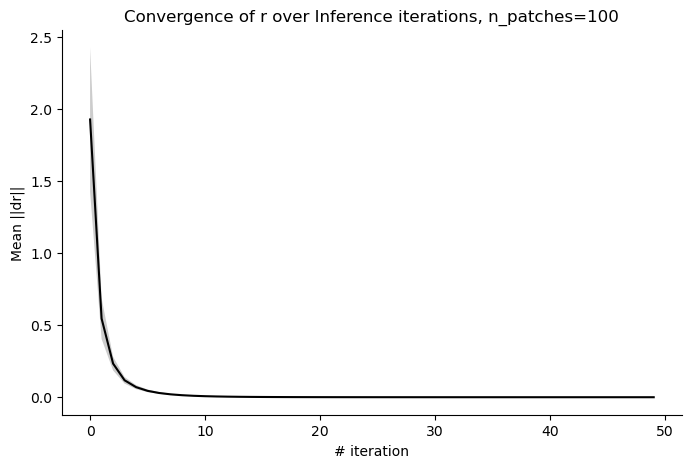

In [ ]:
hf.r_convergence(model_dense, dataset, n=100)


mean |r|  = 0.1818
std r     = 0.2353
kurtosis  = 3.79
sparsity (|r|<0.1) = 0.36
sparsity (|r|<0.5) = 0.96
percentiles: 50%=0.146 75%=0.257 90%=0.386 99%=0.650


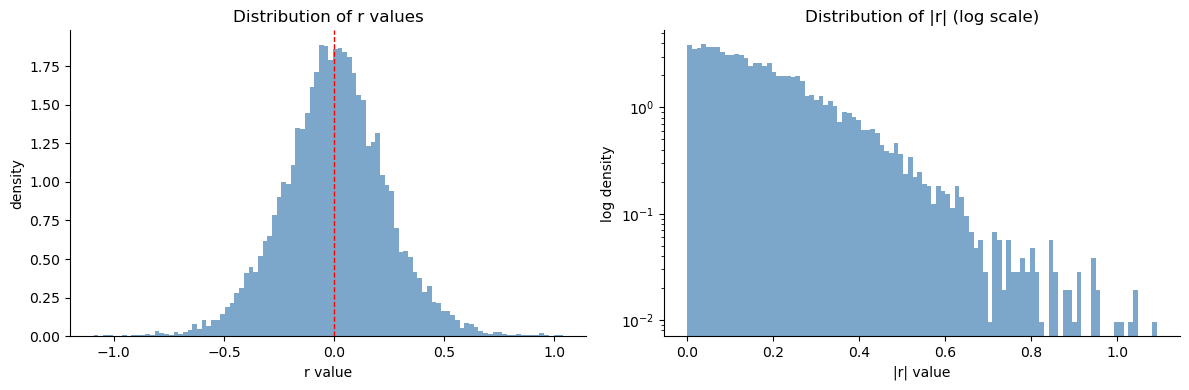

In [ ]:
hf.plot_r_distribution(model_dense, dataset, n_samples=100, sparse=False, savefile="figures/r_dist_dense.jpg")

mean |rh|  = 0.1004
std r     = 0.1271
kurtosis  = 3.24
sparsity (|r|<0.1) = 0.58
sparsity (|r|<0.5) = 1.00
percentiles: 50%=0.084 75%=0.143 90%=0.209 99%=0.341


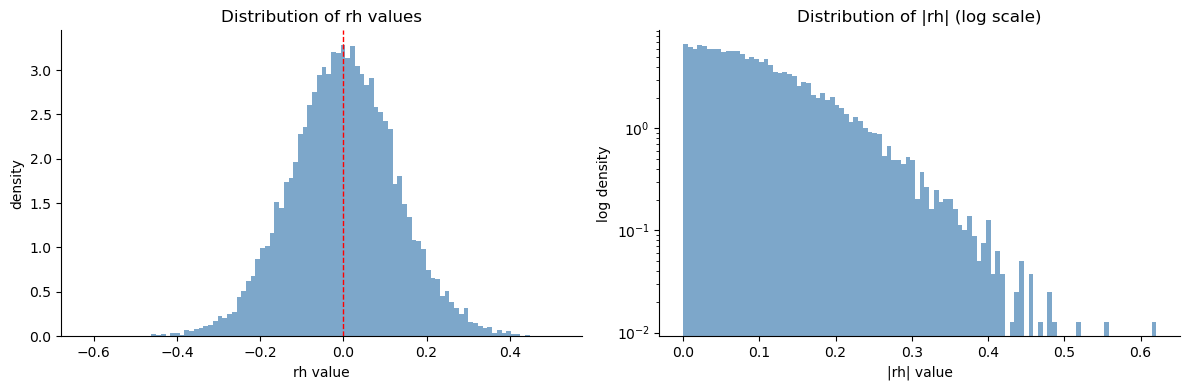

array([ 0.09714905, -0.01283305,  0.13940945, ...,  0.11356308,
       -0.1919319 ,  0.09011738])

In [ ]:
hf.plot_rh_distribution(model_dense, dataset, n_samples=100, sparse=False, savefile="figures/rh_dist_dense_rh.jpg")

In [ ]:
model_dense.save("modelResults/final_workingmodel_dense_model_50iter_1epoch_55000patches_saved4May")

saved: modelResults/final_workingmodel_dense_model_50iter_1epoch_55000patches_saved4May


In [46]:
model_sparse.save("modelResults/final_workingmodel_sparse_model_50iter_1epoch_55000patches_saved4May")

saved: modelResults/final_workingmodel_sparse_model_50iter_1epoch_55000patches_saved4May


In [47]:
model_notd.save("modelResults/final_workingmodel_dense_model_notd_50iter_1epoch_55000patches_saved4May")

saved: modelResults/final_workingmodel_dense_model_notd_50iter_1epoch_55000patches_saved4May


# Sparse Coding Model

In [11]:
model_sparse = Model(iteration=50, alpha2 = 0.05,lambd2 = 0.01,lambd1=0.01, k1=0.05, k2_init=0.01, sigma_sq_td=5)
model_sparse.alpha1 = 5

In [ ]:
#for i in range(5): # 3 epochs
#    model_sparse.train_batch(dataset, batch_size=500, shuffle=True, sparse=True)

Batch 0
Batch 50
Batch 100
train finished
Batch 0
Batch 50
Batch 100
train finished
Batch 0
Batch 50
Batch 100
train finished
Batch 0
Batch 50
Batch 100
train finished
Batch 0
Batch 50
Batch 100
train finished


In [12]:
for i in range(1):  
    model_sparse.train_sparse(dataset)

Sample0
Sample500
Sample1000
Sample1500
Sample2000
Sample2500
Sample3000
Sample3500
Sample4000
Sample4500
Sample5000
Sample5500
Sample6000
Sample6500
Sample7000
Sample7500
Sample8000
Sample8500
Sample9000
Sample9500
Sample10000
Sample10500
Sample11000
Sample11500
Sample12000
Sample12500
Sample13000
Sample13500
Sample14000
Sample14500
Sample15000
Sample15500
Sample16000
Sample16500
Sample17000
Sample17500
Sample18000
Sample18500
Sample19000
Sample19500
Sample20000
Sample20500
Sample21000
Sample21500
Sample22000
Sample22500
Sample23000
Sample23500
Sample24000
Sample24500
Sample25000
Sample25500
Sample26000
Sample26500
Sample27000
Sample27500
Sample28000
Sample28500
Sample29000
Sample29500
Sample30000
Sample30500
Sample31000
Sample31500
Sample32000
Sample32500
Sample33000
Sample33500
Sample34000
Sample34500
Sample35000
Sample35500
Sample36000
Sample36500
Sample37000
Sample37500
Sample38000
Sample38500
Sample39000
Sample39500
Sample40000
Sample40500
Sample41000
Sample41500
Sample42000
Samp

In [ ]:
#model_sparse.save("modelResults/working_sparse_model_lam_5_K_32_50iter_1epoch_55000patches")

saved: modelResults/working_sparse_model_lam_5_K_32_50iter_1epoch_55000patches


In [37]:
model_sparse = model_sparse.load("modelResults/working_sparse_model_lam_5_K_32_50iter_1epoch_55000patches")

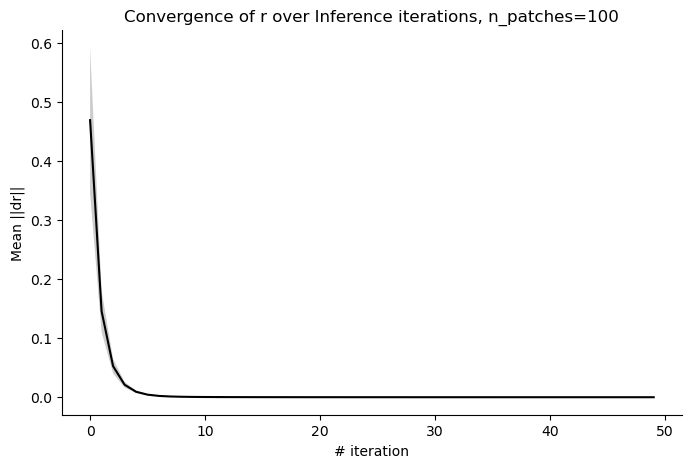

In [13]:

r_convergence(model_sparse, dataset, n=100)


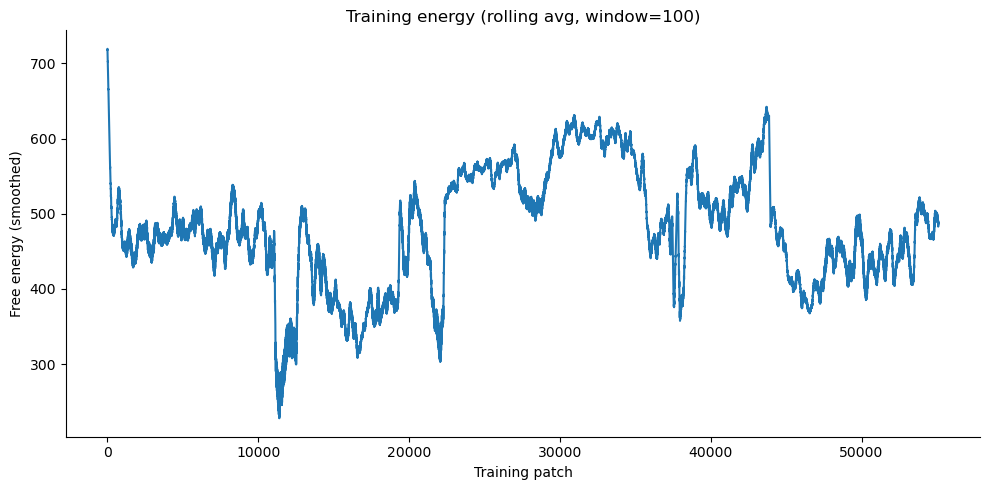

Initial energy (avg first 100):  718.20
Final energy   (avg last  100):  486.87
Reduction: 32.2%


In [14]:
plot_energy(np.array(model_sparse.prior_r) + np.array(model_sparse.prior_rh) + np.array(model_sparse.prior_U) + np.array(model_sparse.prior_uh)+np.array(model_sparse.energy)+np.array(model_sparse.energy_l2), savefile="figures/sparse_energy.jpg", window=100)

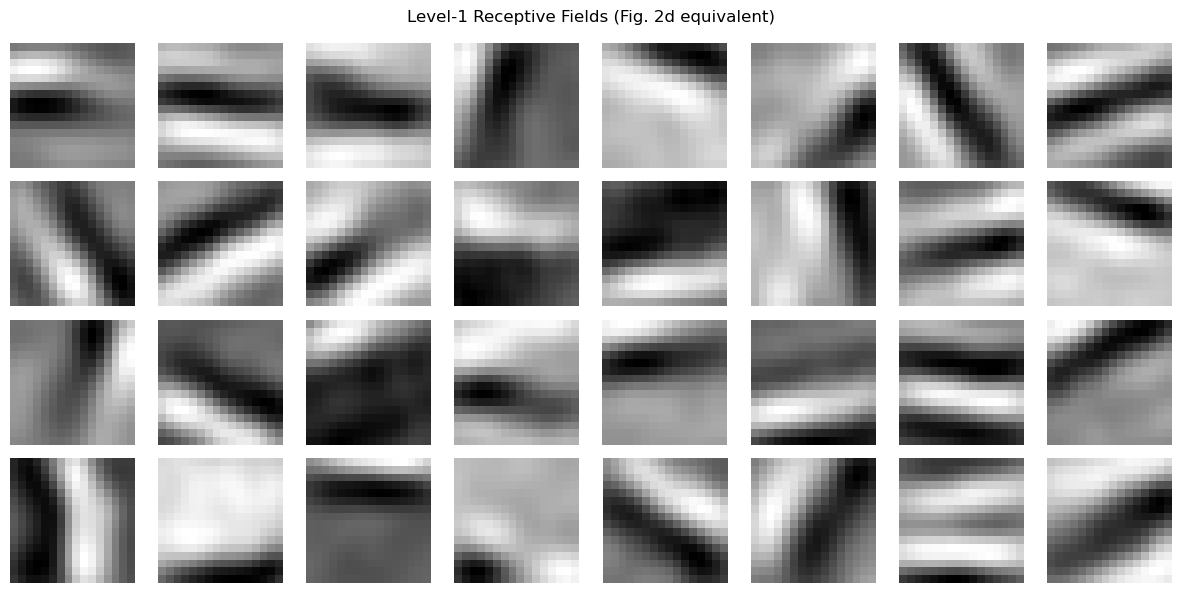

In [15]:
fig, ax = plt.subplots(4, 8, figsize=(12, 6))
    
#u1 = model.Us[1][:,i].reshape(16,16)
#u1 = cv2.resize(u1, None, fx=4, fy=4, interpolation=cv2.INTER_NEAREST)
#imageio.imwrite("result/u1_{:0>2}.png".format(i), u1)

ax = ax.flatten()
for i in range(32):
    u1 = model_sparse.Us[1][:,i].reshape(16,16)
    ax[i].imshow(u1, cmap='gray', interpolation='nearest')
    ax[i].axis('off')
fig.suptitle("Level-1 Receptive Fields (Fig. 2d equivalent)")
plt.tight_layout()

#plt.savefig("figures/receptive_fields_l1_sparse.png", dpi=150)
plt.show()

In [15]:
fig, ax = plt.subplots(8, 16, figsize=(120, 60))
ax = ax.flatten()
for i in range(128):
    u1 = model_sparse.get_level2_rf(i)
    ax[i].imshow(u1, cmap='gray', interpolation='nearest')
    ax[i].axis('off')
fig.suptitle("Level-2 Receptive Fields (Fig. 2d equivalent)")
plt.tight_layout()

plt.savefig("figures/receptive_fields_l2_sparse.png", dpi=150)
plt.show()

bu=0.07712 | td=0.00023 | prior=0.07690
bu=0.09292 | td=0.00026 | prior=0.09267
bu=0.08459 | td=0.00025 | prior=0.08448
bu=0.10399 | td=0.00090 | prior=0.10099
bu=0.07965 | td=0.00092 | prior=0.07621
bu=0.09204 | td=0.00111 | prior=0.08937
bu=0.07573 | td=0.00024 | prior=0.07552
bu=0.08507 | td=0.00027 | prior=0.08481
bu=0.06891 | td=0.00075 | prior=0.06610
bu=0.10290 | td=0.00074 | prior=0.10111


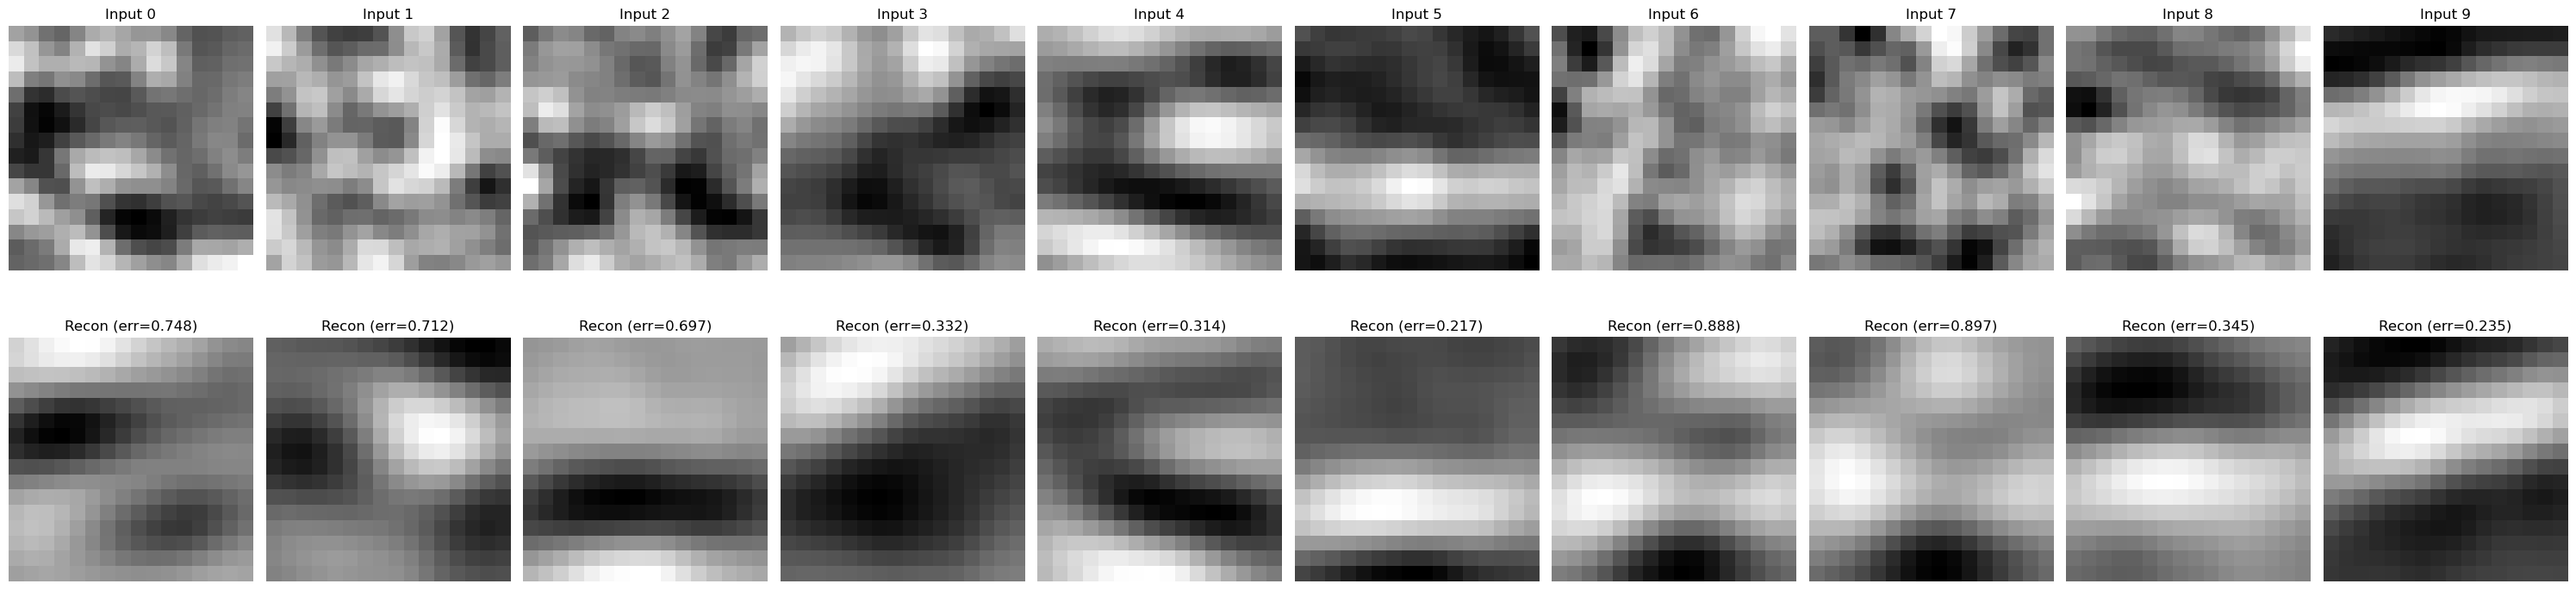

In [ ]:
hf.plot_reconstructions(model_sparse, dataset, n=10, sparse=True, savefile="figures/sparse_recon.jpg")

mean |r|  = 0.2537
std r     = 0.5869
kurtosis  = 75.02
sparsity (|r|<0.1) = 0.33
sparsity (|r|<0.5) = 0.93
percentiles: 50%=0.159 75%=0.283 90%=0.436 99%=2.752


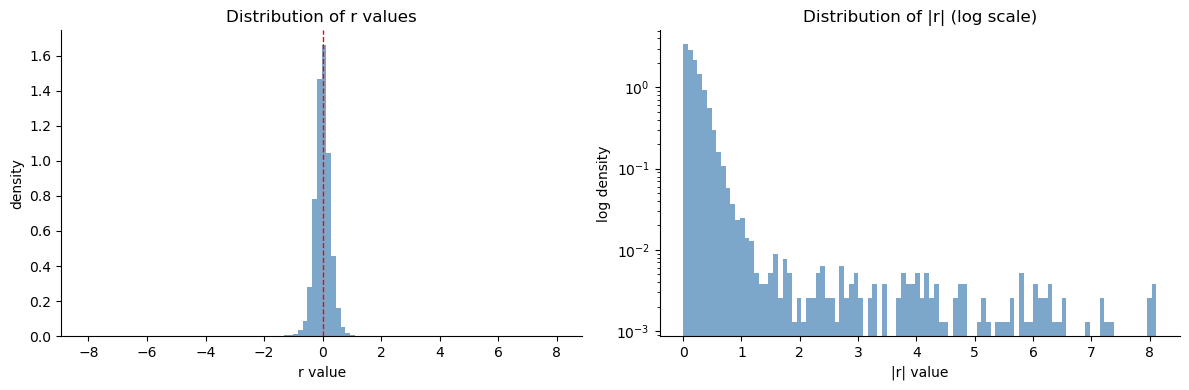

In [ ]:
hf.plot_r_distribution(model_sparse, dataset, n_samples=100, sparse=True, savefile="figures/r_distribution_sparse.jpg")


mean |rh|  = 0.2290
std r     = 0.3233
kurtosis  = 6.35
sparsity (|r|<0.1) = 0.33
sparsity (|r|<0.5) = 0.89
percentiles: 50%=0.160 75%=0.307 90%=0.518 99%=1.072


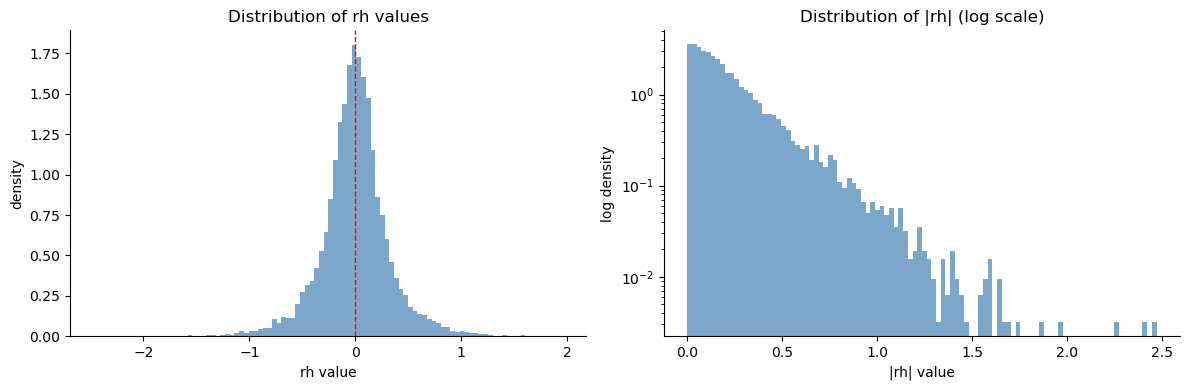

array([-0.76608124, -0.52271593,  0.12702416, ..., -0.23933764,
        0.28609464, -0.04812195])

In [ ]:
hf.plot_rh_distribution(model_sparse, dataset, n_samples=100, sparse=True, savefile="figures/rh_distribution_sparse_rh_dense.jpg")

# Endstopping Results

In [ ]:
bar_patches = [hf.get_bar_patch(i, dataset.patches) for i in range(26)]

In [ ]:

err_neurs = hf.plot_endstopping(model_dense,bar_patches, dataset)

# Model Without Feedback

In [27]:
model_notd = Model(iteration=50, alpha2 = 0.05,lambd2 = 0.01,lambd1=0.1, k1=0.1, k2_init=0.01, sigma_sq_td=1e8) #Model(iteration=50,lambd2 = 1e-5, k1=0.5, sigma_sq_td=1e8, k2_init=1e-6)

In [28]:
model_notd.train(dataset)

Sample0
Sample500
Sample1000
Sample1500
Sample2000
Sample2500
Sample3000
Sample3500
Sample4000
Sample4500
Sample5000
Sample5500
Sample6000
Sample6500
Sample7000
Sample7500
Sample8000
Sample8500
Sample9000
Sample9500
Sample10000
Sample10500
Sample11000
Sample11500
Sample12000
Sample12500
Sample13000
Sample13500
Sample14000
Sample14500
Sample15000
Sample15500
Sample16000
Sample16500
Sample17000
Sample17500
Sample18000
Sample18500
Sample19000
Sample19500
Sample20000
Sample20500
Sample21000
Sample21500
Sample22000
Sample22500
Sample23000
Sample23500
Sample24000
Sample24500
Sample25000
Sample25500
Sample26000
Sample26500
Sample27000
Sample27500
Sample28000
Sample28500
Sample29000
Sample29500
Sample30000
Sample30500
Sample31000
Sample31500
Sample32000
Sample32500
Sample33000
Sample33500
Sample34000
Sample34500
Sample35000
Sample35500
Sample36000
Sample36500
Sample37000
Sample37500
Sample38000
Sample38500
Sample39000
Sample39500
Sample40000
Sample40500
Sample41000
Sample41500
Sample42000
Samp

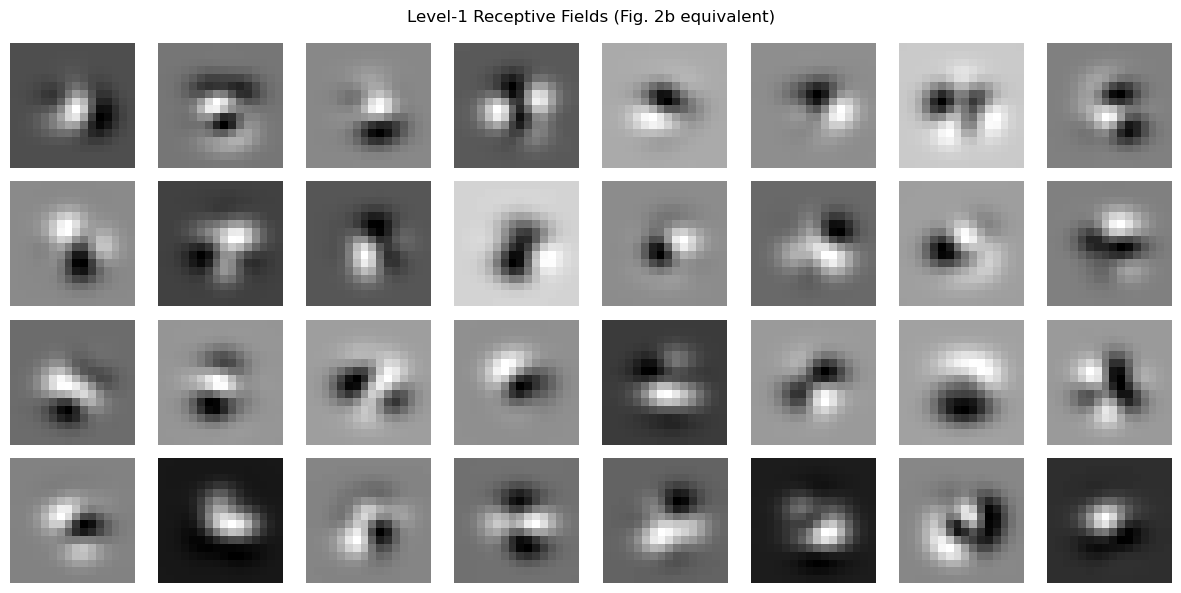

In [29]:
fig, ax = plt.subplots(4, 8, figsize=(12, 6))
    
#u1 = model.Us[1][:,i].reshape(16,16)
#u1 = cv2.resize(u1, None, fx=4, fy=4, interpolation=cv2.INTER_NEAREST)
#imageio.imwrite("result/u1_{:0>2}.png".format(i), u1)

ax = ax.flatten()
for i in range(32):
    u1 = model_notd.Us[1][:,i].reshape(16,16)
    ax[i].imshow(u1, cmap='gray', interpolation='nearest')
    ax[i].axis('off')
fig.suptitle("Level-1 Receptive Fields (Fig. 2b equivalent)")
plt.tight_layout()

#plt.savefig("figures/receptive_fields_l1_dense.png", dpi=150)
plt.show()

In [ ]:
err_neurs_notd=hf.plot_endstopping(model_notd,bar_patches, dataset, savefile="figures/endstopping_dense_nofeed.jpg", l2 =False)

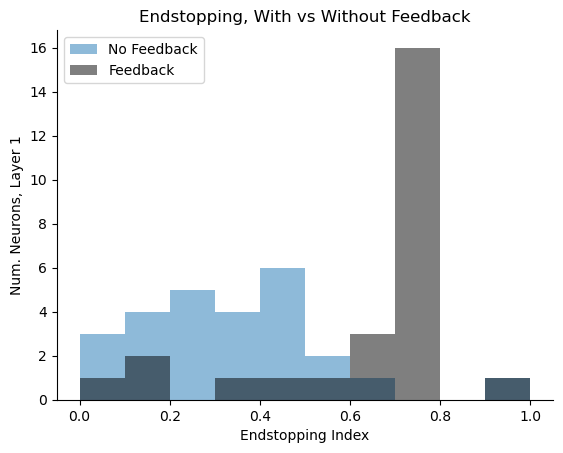

In [ ]:
fig, ax = plt.subplots(1,1)
ESI_notd = hf.calc_errneur_endstopping(err_neurs_notd)
ax.hist(ESI_notd, alpha=0.5)
#ESI_notd = calc_errneur_endstopping(err_neurs_notd)
ax.hist(ESI, alpha=0.5, color='k')
ax.legend(["No Feedback", "Feedback"])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Endstopping Index')
ax.set_title('Endstopping, With vs Without Feedback')
ax.set_ylabel('Num. Neurons, Layer 1')
plt.savefig('figures/endstopping_hist.jpg')

([], [])

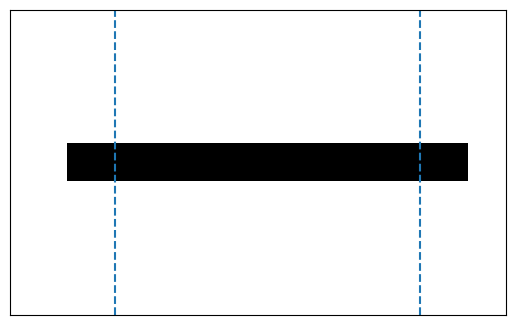

In [200]:
plt.imshow(bar_patches[21], cmap='grey')
plt.axvline(x=5, linestyle='--')
plt.axvline(x=5+16, linestyle='--')
plt.xticks([])
plt.yticks([])

# MAP Estimate With Noisy Input

Currently, the above models perform MAP over the sensory input (images) to estimate neural response (r). Now, the goal is to estimate the posterior probability using noisy input. 
We shall try this over the same trained dense coding model with a Gaussian prior. 

In [49]:
# let's try this over 10 patches

np.random.seed(0)
numpatches = dataset.patches.shape[0]
num_patches_select = 11
idx_patches = np.random.randint(0, numpatches, size=(num_patches_select))

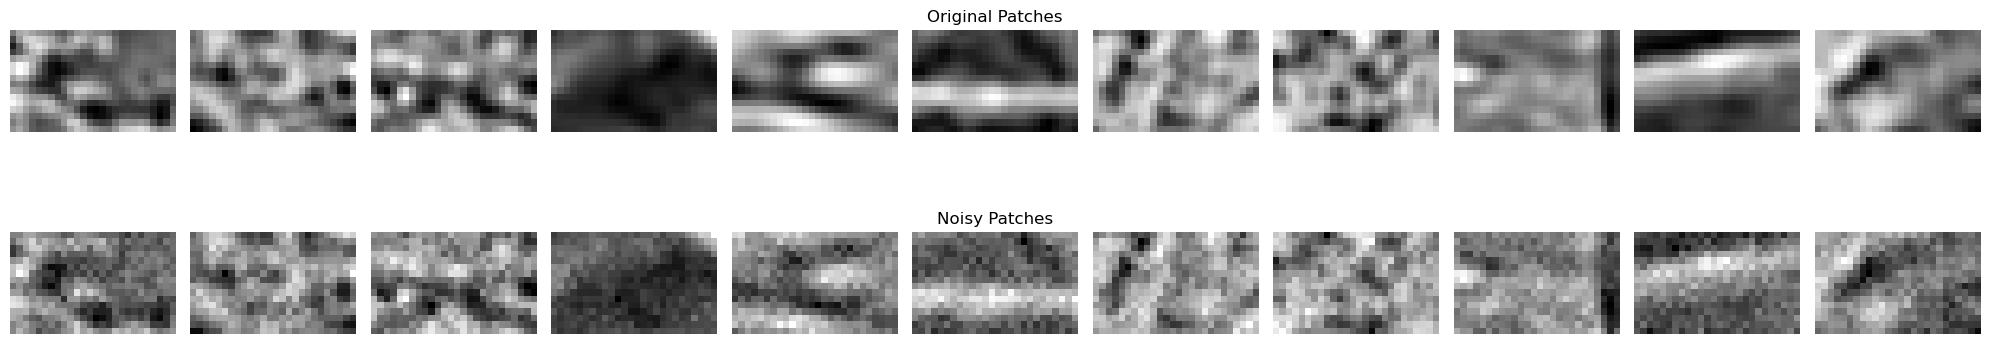

In [52]:
# Add noise to patches. Ensure that the noise is not significantly greater than the pathc values themselves

_, ax = plt.subplots(2,num_patches_select, figsize= (20,5))

for i in range(num_patches_select):
    patch = dataset.patches[idx_patches[i]]
    ax[0,i].imshow(patch, cmap='gray')
    ax[1,i].imshow(patch + np.random.normal(size=(patch.shape), scale=0.4),cmap='gray')
    ax[0,i].axis('off')
    ax[1,i].axis('off')
    if i == int(num_patches_select//2):
        ax[0,i].set_title('Original Patches')
        ax[1,i].set_title('Noisy Patches')
plt.tight_layout()
plt.savefig('figures/noisypatches.jpg')


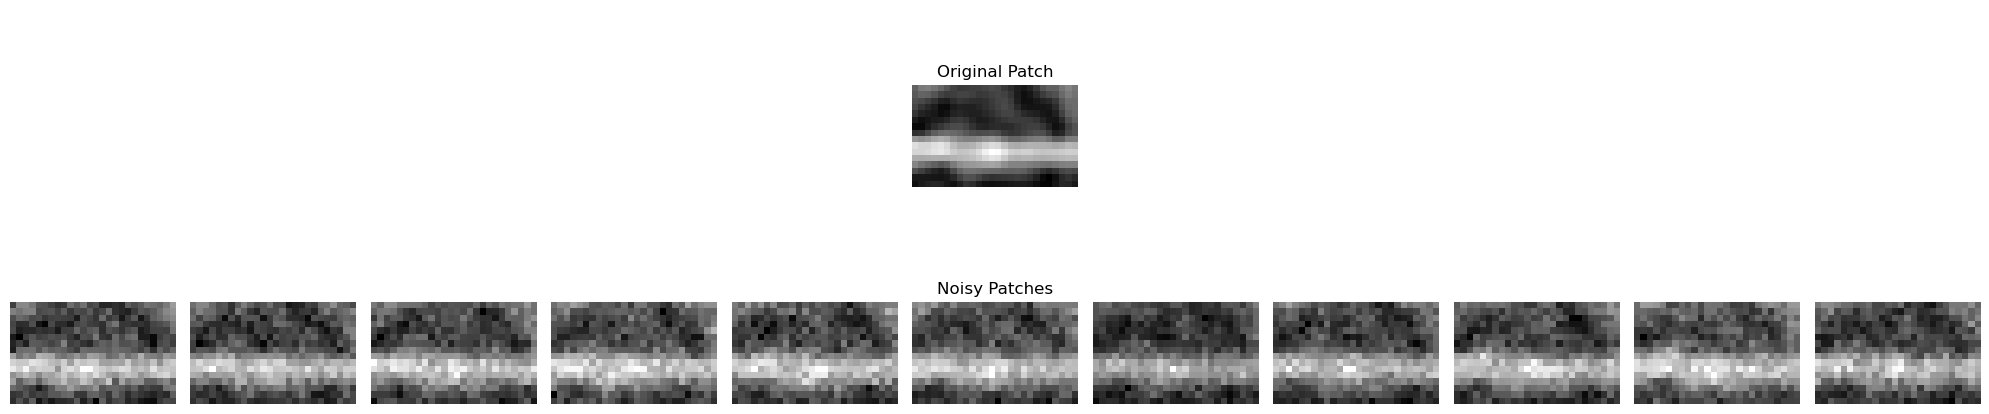

In [307]:
_, ax = plt.subplots(2,num_patches_select, figsize= (20,5))
patch = dataset.patches[idx_patches[5]]
ax[0,5].imshow(patch, cmap='gray')

for i in range(num_patches_select):
    
    ax[1,i].imshow(patch + np.random.normal(size=(patch.shape), scale=0.4),cmap='gray')
    ax[0,i].axis('off')
    ax[1,i].axis('off')
    if i == int(num_patches_select//2):
        ax[0,i].set_title('Original Patch')
        ax[1,i].set_title('Noisy Patches')

plt.tight_layout()


In [54]:
# run inference over this model 

def noisy_inference(model,bars, sparse=False):
    n = len(bars)
    rs_all = []
    r_tds_all = []
    error_tds_all = []
    rh_all = []
    for idx in range(n):
        images = []
        for i in range(3):
            x = dataset.overlap * i
            # Apply gaussian mask
            image = bars[idx][:, x:x+dataset.h_pix].reshape([-1])
            if sparse:
                image = image * dataset.mask

            images.append(image)
        if sparse:
            rs, r_tds, rh, error_tds,_,_ = model.apply_images_sparse(
                images, training=False)
        else:
            rs, r_tds, rh, error_tds,_,_ = model.apply_images(
                images, training=False)
            
        rs_all.append(rs)
        rh_all.append(rh)
        r_tds_all.append(r_tds)
        error_tds_all.append(error_tds)
    
    rs_all = np.array(rs_all)
    r_tds_all = np.array(r_tds_all)
    return rs_all, rh_all, r_tds_all, error_tds_all

def generate_noisy_patches(patches, num_noisy=100, noise_mean=0, noise_std=0.4):
    new_patch_dataset = []

    for patch in patches:
        new_patches = np.empty((num_noisy+1,patches.shape[1], patches.shape[2]))
        for i in range(num_noisy):
            new_patches[i,:,:] = patch + np.random.normal(size=(patches.shape[1], patches.shape[2]), loc=noise_mean, scale=noise_std)
        new_patches[-1,:,:] = patch
        new_patch_dataset.append(new_patches)

    return new_patch_dataset


def run_noisy_inf(model, new_patch_dataset, sparse=False, savefile="figures/dense_MAP_noisy.jpg"):

    num_patches = len(new_patch_dataset)
    rs_all_patches = []
    r_tds_all_patches = []
    error_tds_all_patches = []
    rh_all_patches = []
    for noisy_patches in new_patch_dataset:
        rs_all, rh_all, r_tds_all, error_tds_all = noisy_inference(model,noisy_patches, sparse=sparse)
        rs_all_patches.append(rs_all)
        rh_all_patches.append(rh_all)
        r_tds_all_patches.append(r_tds_all)
        error_tds_all_patches.append(error_tds_all)
    
    #print()
    # plot distribution of r_values for any random r over all patches. Note that patch -1 wihin each patches dataset is the true image
    #rand_idx_r = np.random.randint(low=0, size=1, high = )
    _, ax = plt.subplots(2, len(new_patch_dataset), figsize= (30,12))
    for i in range(len(new_patch_dataset)): # inference for each patch 
        rs = np.array(rs_all_patches[i])
        rh = np.array(rh_all_patches[i])
        rand_idx_r = np.random.randint(0, size=1, high=rs[0,:].size) # rs is of shape (noisy_patches, units)
        rand_idx_rh = np.random.randint(0, size=1, high=rh[0,:].size) # rs is of shape (noisy_patches, units)
        _=ax[0,i].hist(rs[:,rand_idx_r], bins=20, density=True)
        _=ax[1,i].hist(rh[:,rand_idx_rh], bins=20, density=True)
        ax[0,i].axvline(x = rs[-1,rand_idx_r], c='r',linestyle="--" )
        ax[1,i].axvline(x = rh[-1,rand_idx_rh], c='r',linestyle="--" )
        if i== 0:
            ax[0,i].set_ylabel("P(rs | Image, Us)")
            ax[1,i].set_ylabel("P(rs | Image, Uh)")
        ax[1,i].set_xlabel("rh")
        ax[0,i].set_xlabel("rs")

    plt.suptitle("Inference over response of level 1 and level 2")
    plt.savefig(savefile)
    plt.show()
    return rs_all_patches, rh_all_patches, r_tds_all, error_tds_all


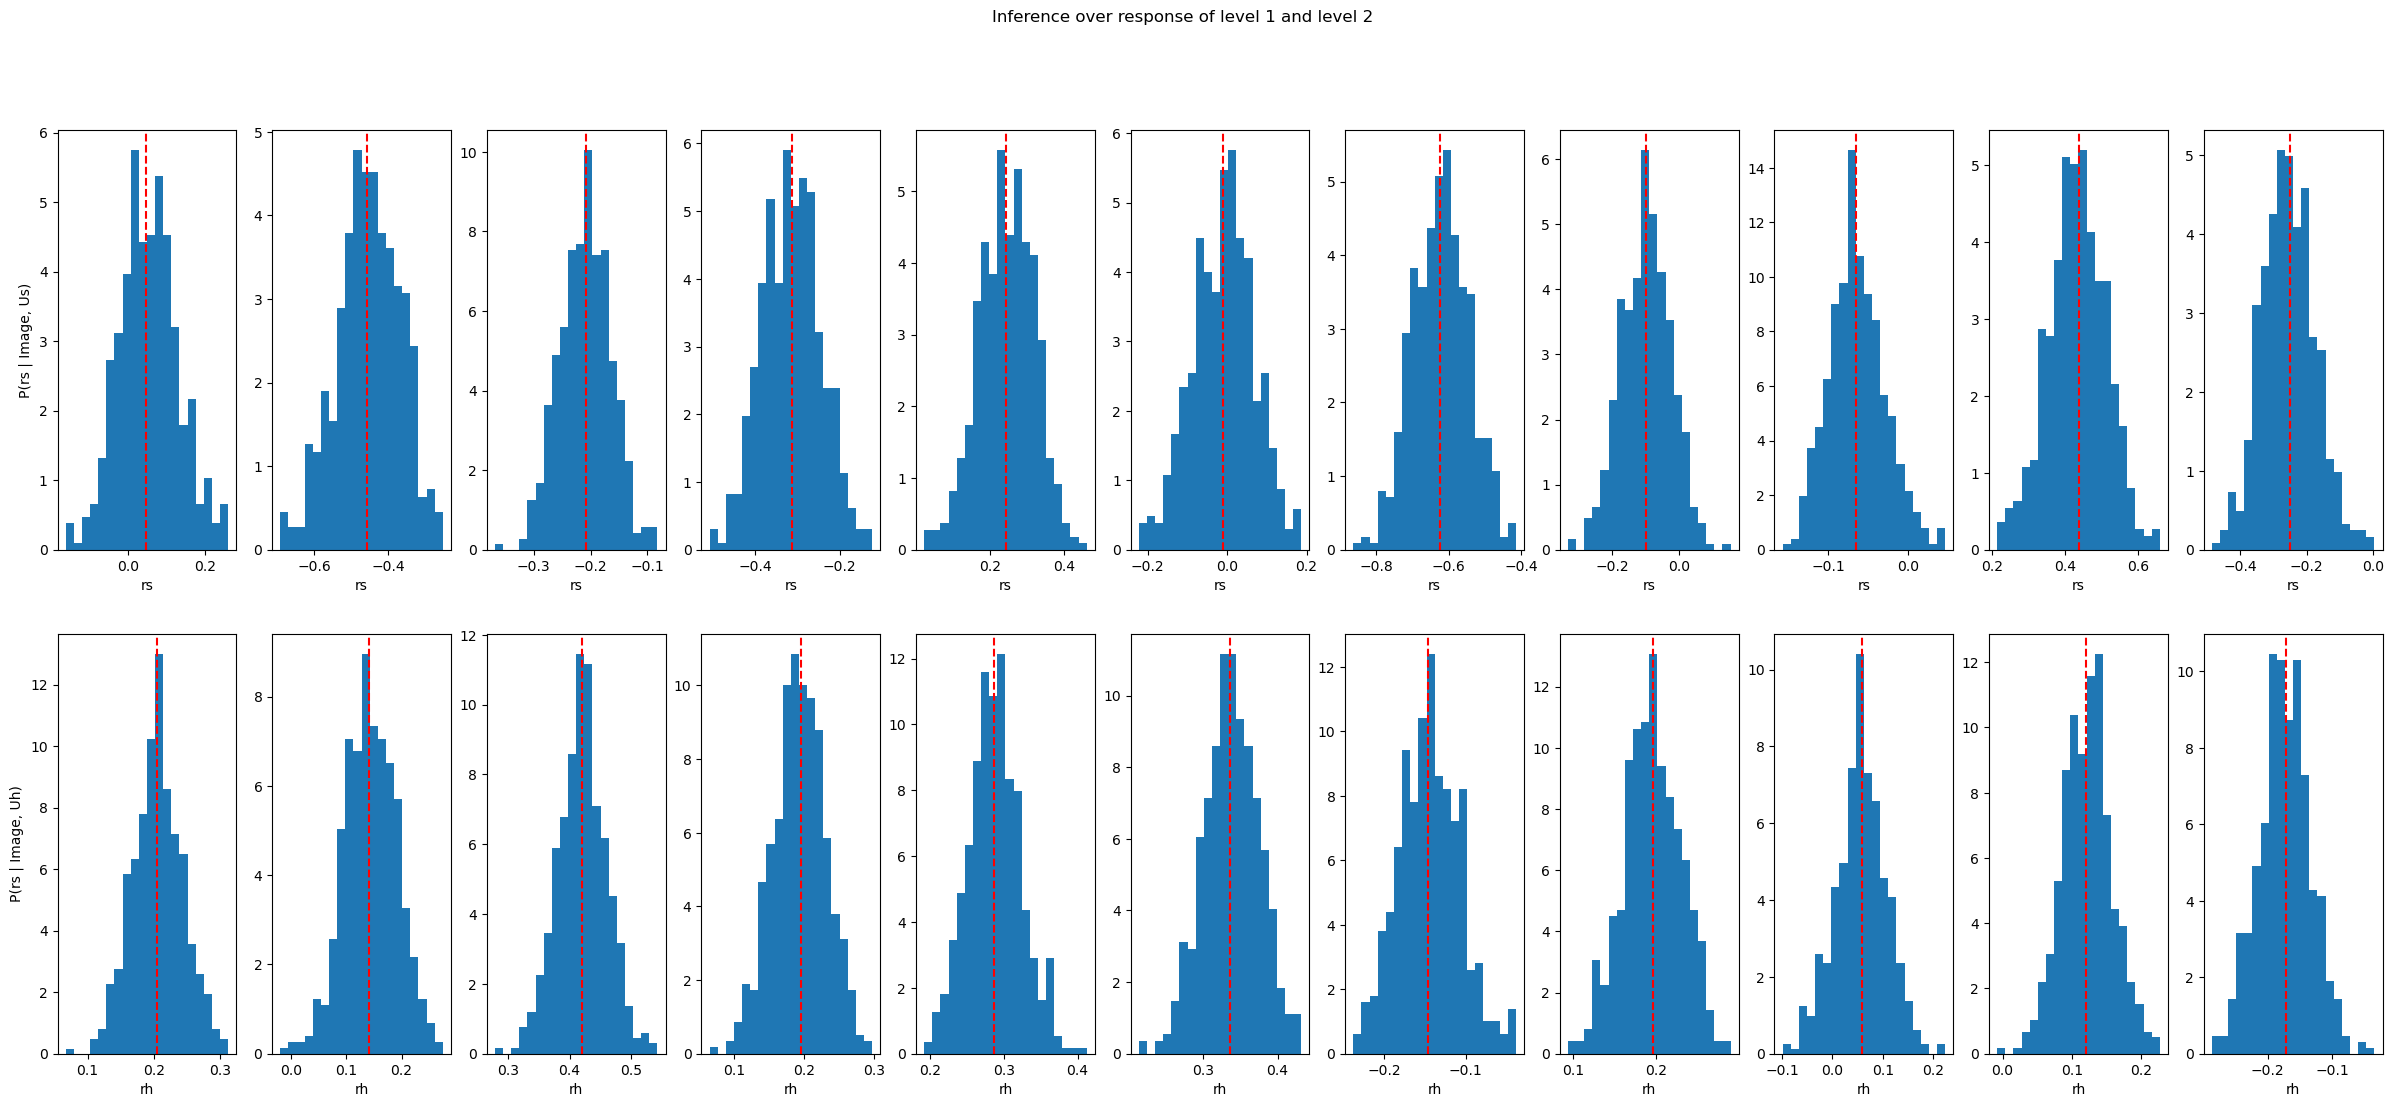

In [55]:
new_patch_dataset = generate_noisy_patches(dataset.patches[idx_patches,:,:], num_noisy=500, noise_std=0.4)
rs_all_noisy,rh_all_noisy,_,_=run_noisy_inf(model_dense, new_patch_dataset)

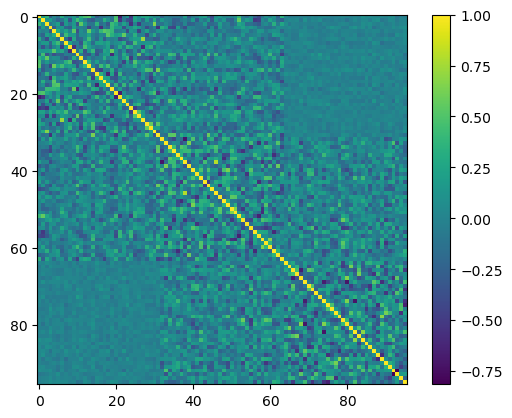

In [435]:
plt.imshow(np.corrcoef(rs_all_noisy[0].T))
plt.colorbar()


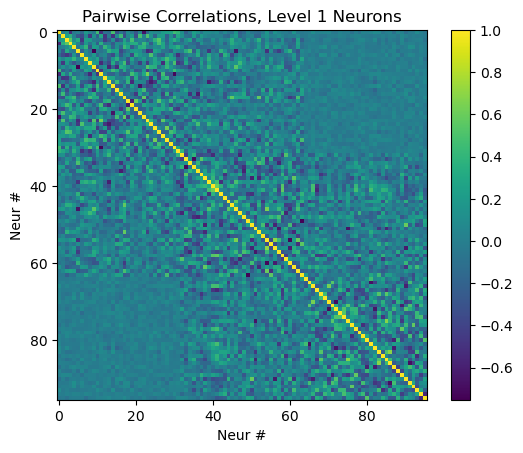

In [ ]:
cov=np.corrcoef((rs_all_noisy[2] - rs_all_noisy[2].mean(axis=0)).T)

std = np.sqrt(np.diag(cov))
corr = cov / (std[:, None] * std[None, :])
plt.imshow(corr)
plt.colorbar()
plt.title('Pairwise Correlations, Level 1 Neurons')
plt.ylabel('Neur #')
plt.xlabel('Neur #')
plt.savefig('figures/cov_matrix.jpg')

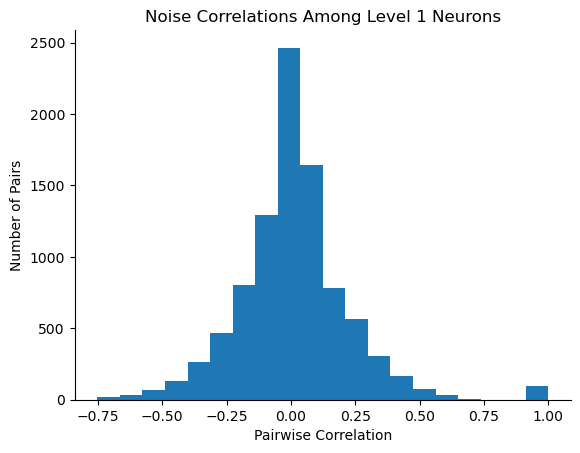

In [61]:
fig, ax = plt.subplots()

ax.hist(corr.flatten(), bins=20)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Pairwise Correlation')
ax.set_ylabel('Number of Pairs')
ax.set_title('Noise Correlations Among Level 1 Neurons')
plt.savefig('figures/pairwise_corr_hist.jpg')


In [62]:
vals = corr[np.triu_indices_from(corr, k=1)]
print(np.mean(vals))
print(np.median(vals))
print(np.std(vals))

0.0009905036227834125
0.0010836382714539887
0.1927398701832524
